Source: https://github.com/Project-MONAI/tutorials/blob/main/2d_classification/mednist_tutorial.ipynb

In [1]:
# !python -c "import monai" || pip install -q "monai-weekly[pillow, tqdm]"
# !python -c "import matplotlib" || pip install -q matplotlib

In [2]:
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
import PIL
import torch
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from sklearn.metrics import classification_report

from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
)
from monai.utils import set_determinism

print_config()

c:\Users\pola3\miniconda3\envs\reg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.10.0+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: c:\Users\<username>\miniconda3\envs\reg\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.2
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.0.0
Tensorboard version: 2.20.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.25.0+cu126
tqdm version: 4.67.3
lmdb version: 2.0.0
psutil version: 7.2.2
pandas version: 2.3.3
einops version: 0.8.2
transformers version: 5.3.0
mlflow version: 3.10.1
pynrrd version: 1.1.3
clearml version: 2.1.3

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [3]:
root_dir = os.environ.get("MONAI_DATA_DIRECTORY", "./vit_data")
os.makedirs(root_dir, exist_ok=True)
print(f"Data will be saved in: {os.path.abspath(root_dir)}")

Data will be saved in: c:\Users\pola3\Desktop\New folder\Диссер\Registration\Code\MSPE\vit_data


In [4]:
resource = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/MedNIST.tar.gz"
md5 = "0bc7306e7427e00ad1c5526a6677552d"

compressed_file = os.path.join(root_dir, "MedNIST.tar.gz")
data_dir = os.path.join(root_dir, "MedNIST")
if not os.path.exists(data_dir):
    download_and_extract(resource, compressed_file, root_dir, md5)

In [5]:
# set_determinism(seed=0)

In [6]:
class_names = sorted(x for x in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, x)))
num_class = len(class_names)
image_files = [
    [os.path.join(data_dir, class_names[i], x) for x in os.listdir(os.path.join(data_dir, class_names[i]))]
    for i in range(num_class)
]
num_each = [len(image_files[i]) for i in range(num_class)]
image_files_list = []
image_class = []
for i in range(num_class):
    image_files_list.extend(image_files[i])
    image_class.extend([i] * num_each[i])
num_total = len(image_class)
image_width, image_height = PIL.Image.open(image_files_list[0]).size

print(f"Total image count: {num_total}")
print(f"Image dimensions: {image_width} x {image_height}")
print(f"Label names: {class_names}")
print(f"Label counts: {num_each}")

Total image count: 58954
Image dimensions: 64 x 64
Label names: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Label counts: [10000, 8954, 10000, 10000, 10000, 10000]


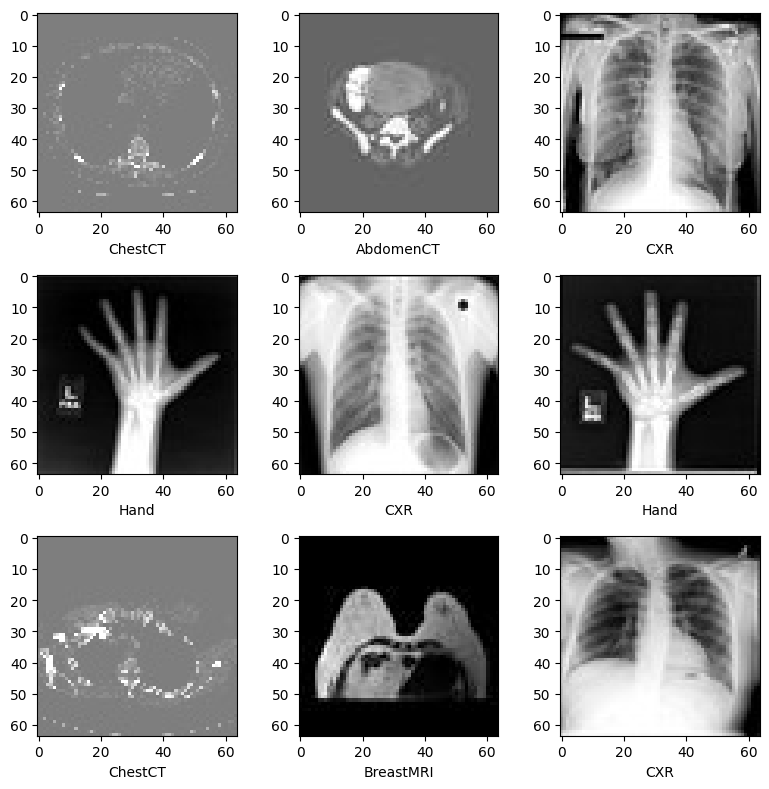

In [7]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(num_total, size=9)):
    im = PIL.Image.open(image_files_list[k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[image_class[k]])
    plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
plt.tight_layout()
plt.show()

In [8]:
# Randomly select 10% of the dataset as validation and 10% as test.
val_frac = 0.1
test_frac = 0.1
length = len(image_files_list)
indices = np.arange(length)
np.random.shuffle(indices)

test_split = int(test_frac * length)
val_split = int(val_frac * length) + test_split
test_indices = indices[:test_split]
val_indices = indices[test_split:val_split]
train_indices = indices[val_split:]

train_x = [image_files_list[i] for i in train_indices]
train_y = [image_class[i] for i in train_indices]
val_x = [image_files_list[i] for i in val_indices]
val_y = [image_class[i] for i in val_indices]
test_x = [image_files_list[i] for i in test_indices]
test_y = [image_class[i] for i in test_indices]

print(f"Training count: {len(train_x)}, Validation count: " f"{len(val_x)}, Test count: {len(test_x)}")

Training count: 47164, Validation count: 5895, Test count: 5895


In [9]:
train_transforms = Compose(
    [
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        ScaleIntensity(),
        RandRotate(range_x=np.pi / 12, prob=0.5, keep_size=True),
        RandFlip(spatial_axis=0, prob=0.5),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ]
)

val_transforms = Compose([LoadImage(image_only=True), EnsureChannelFirst(), ScaleIntensity()])

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_class)])

In [10]:
class MedNISTDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds = MedNISTDataset(train_x, train_y, train_transforms)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(val_x, val_y, val_transforms)
val_loader = DataLoader(val_ds, batch_size=64, num_workers=0)

test_ds = MedNISTDataset(test_x, test_y, val_transforms)
test_loader = DataLoader(test_ds, batch_size=64, num_workers=0)

In [11]:
import monai
from monai.networks.blocks import PatchEmbeddingBlock
from mspe import MSPEPatchEmbedd
device = torch.device("cuda")

# customPatchEmbeddingBlock = PatchEmbeddingBlock(in_channels=1, spatial_dims = 2, 
#                                             img_size = 64, patch_size=16, 
#                                             hidden_size=256, num_heads=4,
#                                             proj_type="conv", pos_embed_type="learnable")

customPatchEmbeddingBlock = MSPEPatchEmbedd(in_channels=1, spatial_dims = 2, 
                                            img_size = 64, patch_size=16, 
                                            hidden_size=256, num_heads=4,
                                            pos_embed_type="learnable", 
                                            K=4, resolutions=[32, 48, 64, 80, 96, 128])


print(customPatchEmbeddingBlock, "\n")

# small ViT for fast training 
model = monai.networks.nets.ViT( 
    in_channels = 1,
    patch_size = 16,
    img_size = 64,
    spatial_dims = 2,
    hidden_size = 256, 
    mlp_dim = 1024,
    num_layers = 6,
    num_heads = 4,
    num_classes = 6,
    classification = True,
).to(device)

model.patch_embedding = customPatchEmbeddingBlock.to(device)

MSPEPatchEmbedd(
  patch_size=(16, 16), in_channels=1, hidden_size=256, img_size=64, K=4, N=4, kernel_sizes=[(4, 4), (8, 8), (12, 12), (16, 16)], resolutions=[32, 48, 64, 80, 96, 128]
  (dropout): Dropout(p=0.0, inplace=False)
  (patch_kernels): ModuleList(
    (0): Conv2d(1, 256, kernel_size=(4, 4), stride=(4, 4))
    (1): Conv2d(1, 256, kernel_size=(8, 8), stride=(8, 8))
    (2): Conv2d(1, 256, kernel_size=(12, 12), stride=(12, 12))
    (3): Conv2d(1, 256, kernel_size=(16, 16), stride=(16, 16))
  )
) 



In [12]:
from torchinfo import summary
summary(model, input_size=(1, 1, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
ViT                                      [1, 6]                    256
├─MSPEPatchEmbedd: 1-1                   [1, 16, 256]              128,000
│    └─Dropout: 2-1                      [1, 16, 256]              --
├─ModuleList: 1-2                        --                        --
│    └─TransformerBlock: 2-2             [1, 17, 256]              262,912
│    │    └─LayerNorm: 3-1               [1, 17, 256]              512
│    │    └─SABlock: 3-2                 [1, 17, 256]              262,400
│    │    └─LayerNorm: 3-3               [1, 17, 256]              512
│    │    └─MLPBlock: 3-4                [1, 17, 256]              525,568
│    └─TransformerBlock: 2-3             [1, 17, 256]              262,912
│    │    └─LayerNorm: 3-5               [1, 17, 256]              512
│    │    └─SABlock: 3-6                 [1, 17, 256]              262,400
│    │    └─LayerNorm: 3-7               [1, 17, 25

In [13]:
# run current embeddings z through ViT encoder and classification head
def forward_encoder(model, z):
    
    #  prepend a cls_token for Vit
    cls_tokens = model.cls_token.expand(z.shape[0], -1, -1)
    z = torch.cat([cls_tokens, z], dim=1)
    
    # transformer blocks
    for blk in model.blocks:
        z = blk(z)
    z = model.norm(z)
    
    # classification head on cls_token
    if model.classification:
        z = model.classification_head(z[:, 0])
    return z

In [14]:
# MSPE-ViT train loop 

from mspe import img_resize

loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-5)
max_epochs = 10
val_interval = 1
auc_metric = ROCAUCMetric()
writer = SummaryWriter()

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []


lambda_reg = 1.0  # for aliigning with default resolution of 64 by 64 

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()

        total_loss = torch.tensor(0.0, device=device)

        # get K = 4 random resolutions from predifined resolutions 
        hw_list = model.patch_embedding.sample_resolutions()

        # for each sampled resolution 
        for k, hw in enumerate(hw_list):
            # billinearly resize img
            img_k = img_resize(inputs, hw)
            # embeddings forward using the closest kernel K to resolution img_k
            z_k = model.patch_embedding.forward_k(img_k, func_idx=k, hw=hw)
            # encoder forward
            y_k = forward_encoder(model, z_k)
            # total loss
            total_loss = total_loss + loss_function(y_k, labels)

        # original resolution 64 by 64 forward
        outputs = model(inputs)[0] 
        total_loss = total_loss + lambda_reg* loss_function(outputs, labels)
        # starting from here the code is unchanged compared to vanilla ViT train/eval
        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {total_loss.item():.4f}")
        epoch_len = len(train_ds) // train_loader.batch_size
        writer.add_scalar("train_loss", total_loss.item(), epoch_len * epoch + step)
        
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")


    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            y_pred = torch.tensor([], dtype=torch.float32, device=device)
            y = torch.tensor([], dtype=torch.long, device=device)
            for val_data in val_loader:
                val_images, val_labels = (
                    val_data[0].to(device),
                    val_data[1].to(device),
                )
                y_pred = torch.cat([y_pred, model(val_images)[0]], dim=0)
                y = torch.cat([y, val_labels], dim=0)
            y_onehot = [y_trans(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)
            acc_value = torch.eq(y_pred.argmax(dim=1), y)
            acc_metric = acc_value.sum().item() / len(acc_value)
            if result > best_metric:
                best_metric = result
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current accuracy: {acc_metric:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
            writer.add_scalar("val_accuracy", acc_metric, epoch + 1)

print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")
writer.close()


1/736, train_loss: 9.9410
2/736, train_loss: 9.2327
3/736, train_loss: 9.0591
4/736, train_loss: 8.9273
5/736, train_loss: 8.7755
6/736, train_loss: 8.6452
7/736, train_loss: 8.3919
8/736, train_loss: 8.3902
9/736, train_loss: 8.2064
10/736, train_loss: 8.0959
11/736, train_loss: 7.9221
12/736, train_loss: 7.9764
13/736, train_loss: 7.8779
14/736, train_loss: 7.8640
15/736, train_loss: 7.6948
16/736, train_loss: 7.6112
17/736, train_loss: 7.4365
18/736, train_loss: 7.4199
19/736, train_loss: 7.1069
20/736, train_loss: 7.6971
21/736, train_loss: 7.2239
22/736, train_loss: 7.3969
23/736, train_loss: 7.1137
24/736, train_loss: 7.0372
25/736, train_loss: 6.9365
26/736, train_loss: 6.7196
27/736, train_loss: 6.7980
28/736, train_loss: 6.7360
29/736, train_loss: 6.7672
30/736, train_loss: 6.6330
31/736, train_loss: 6.3924
32/736, train_loss: 6.1654
33/736, train_loss: 6.3886
34/736, train_loss: 5.9821
35/736, train_loss: 6.1646
36/736, train_loss: 6.1673
37/736, train_loss: 6.0173
38/736, tr

In [15]:
# # monai vanilla ViT train/eval

# loss_function = torch.nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), 3e-5)
# max_epochs = 1
# val_interval = 1
# auc_metric = ROCAUCMetric()


# best_metric = -1
# best_metric_epoch = -1
# epoch_loss_values = []
# metric_values = []
# writer = SummaryWriter()

# for epoch in range(max_epochs):
#     print("-" * 10)
#     print(f"epoch {epoch + 1}/{max_epochs}")
#     model.train()
#     epoch_loss = 0
#     step = 0
#     for batch_data in train_loader:
#         step += 1
#         inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)[0] #ViT
#         loss = loss_function(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#         print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
#         epoch_len = len(train_ds) // train_loader.batch_size
#         writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)
#     epoch_loss /= step
#     epoch_loss_values.append(epoch_loss)
#     print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

#     if (epoch + 1) % val_interval == 0:
#         model.eval()
#         with torch.no_grad():
#             y_pred = torch.tensor([], dtype=torch.float32, device=device)
#             y = torch.tensor([], dtype=torch.long, device=device)
#             for val_data in val_loader:
#                 val_images, val_labels = (
#                     val_data[0].to(device),
#                     val_data[1].to(device),
#                 )
#                 y_pred = torch.cat([y_pred, model(val_images)[0]], dim=0)
#                 y = torch.cat([y, val_labels], dim=0)
#             y_onehot = [y_trans(i) for i in decollate_batch(y, detach=False)]
#             y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
#             auc_metric(y_pred_act, y_onehot)
#             result = auc_metric.aggregate()
#             auc_metric.reset()
#             del y_pred_act, y_onehot
#             metric_values.append(result)
#             acc_value = torch.eq(y_pred.argmax(dim=1), y)
#             acc_metric = acc_value.sum().item() / len(acc_value)
#             if result > best_metric:
#                 best_metric = result
#                 best_metric_epoch = epoch + 1
#                 torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
#                 print("saved new best metric model")
#             print(
#                 f"current epoch: {epoch + 1} current AUC: {result:.4f}"
#                 f" current accuracy: {acc_metric:.4f}"
#                 f" best AUC: {best_metric:.4f}"
#                 f" at epoch: {best_metric_epoch}"
#             )
#             writer.add_scalar("val_accuracy", acc_metric, epoch + 1)

# print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")
# writer.close()

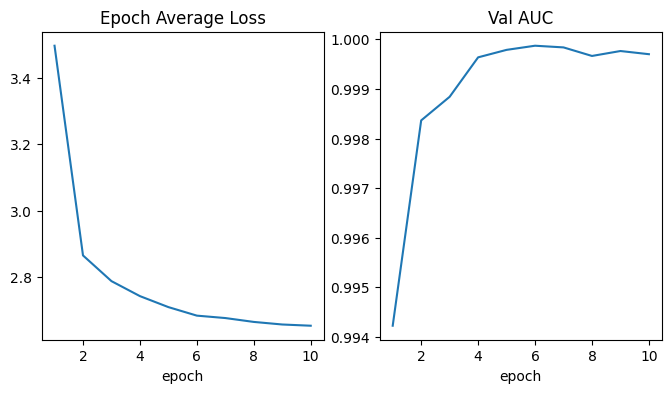

In [16]:
plt.figure("train", (8, 4))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.subplot(1, 2, 2)
plt.title("Val AUC")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y)
plt.show()

In [17]:
# model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = (
            test_data[0].to(device),
            test_data[1].to(device),
        )
        pred = model(test_images)[0].argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

   AbdomenCT     0.9969    0.9929    0.9949       986
   BreastMRI     1.0000    1.0000    1.0000       924
         CXR     1.0000    0.9798    0.9898      1038
     ChestCT     0.9990    1.0000    0.9995       993
        Hand     0.9785    1.0000    0.9891       956
      HeadCT     0.9940    0.9970    0.9955       998

    accuracy                         0.9947      5895
   macro avg     0.9947    0.9949    0.9948      5895
weighted avg     0.9948    0.9947    0.9947      5895

